In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv(r'E:\credit-risk-prediction\dataset\credit_risk_dataset.csv')

In [3]:

# BASIC DATA UNDERSTANDING

print("--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- DATASET INFO ---")
df.info()

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

--- FIRST 5 ROWS ---


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB

--- STATISTICAL SUMMARY

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:

#  DATA QUALITY CHECK

print("--- MISSING VALUES ---")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\n--- DUPLICATE ROWS: {df.duplicated().sum()} ---")

print("\n--- INVALID VALUES CHECK ---")
print(f"Max Age found: {df['person_age'].max()} (Potential Error)")
print(f"Max Employment Length found: {df['person_emp_length'].max()} (Potential Error)")

--- MISSING VALUES ---
person_emp_length     895
loan_int_rate        3116
dtype: int64

--- DUPLICATE ROWS: 165 ---

--- INVALID VALUES CHECK ---
Max Age found: 144 (Potential Error)
Max Employment Length found: 123.0 (Potential Error)


In [5]:

#  HANDLE DUPLICATES / INVALID DATA

# Drop duplicates
initial_count = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped {initial_count - len(df)} duplicate rows.")

#checking removed rows
print("Age > 100:")
display(df[df['person_age'] > 100])

print("Employment length > 80:")
display(df[df['person_emp_length'] > 80])
# Handle domain-impossible outliers (e.g., age > 100 or employment length > 80)
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 80]
print(f"Dataset shape after filtering impossible records: {df.shape}")

Dropped 165 duplicate rows.
Age > 100:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


Employment length > 80:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


Dataset shape after filtering impossible records: (31522, 12)


In [6]:
#checking removed rows
print("Age > 100:")
display(df[df['person_age'] > 100])

print("Employment length > 80:")
display(df[df['person_emp_length'] > 80])

Age > 100:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


Employment length > 80:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


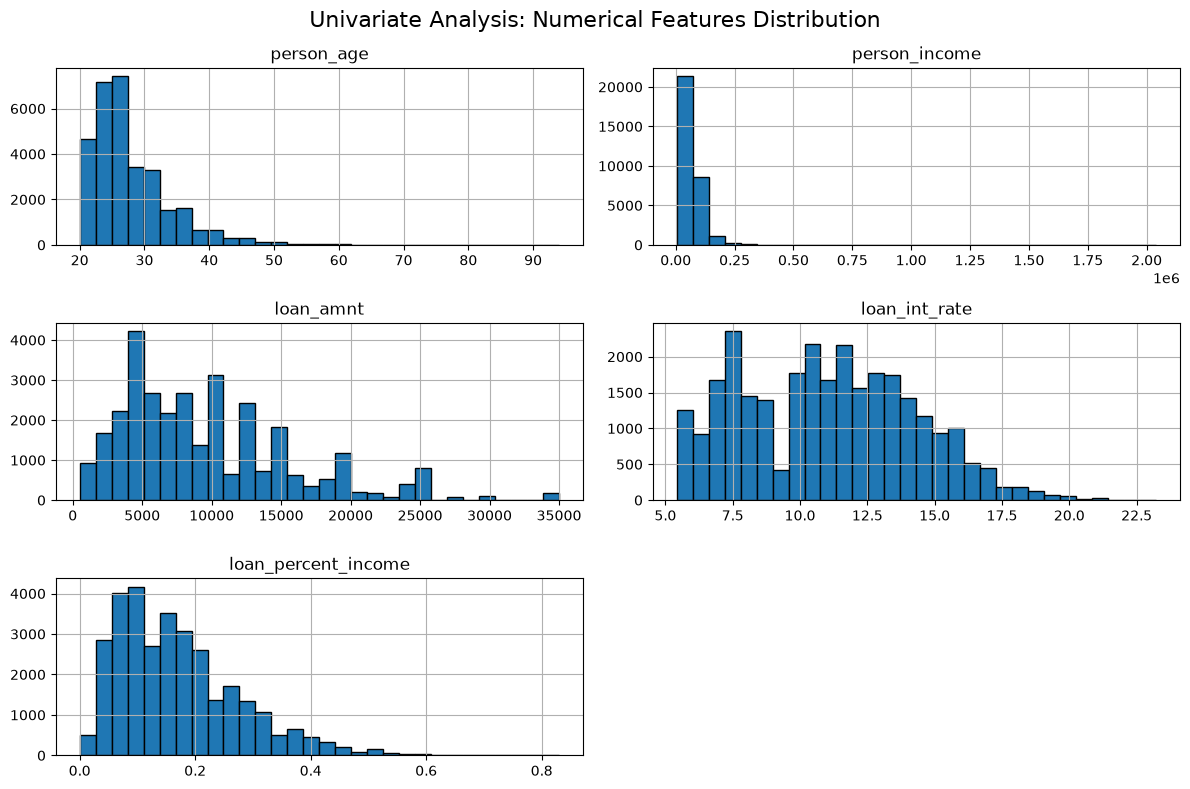

C:\Users\btirk\AppData\Local\Temp\ipykernel_14964\3158000715.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='Set2')


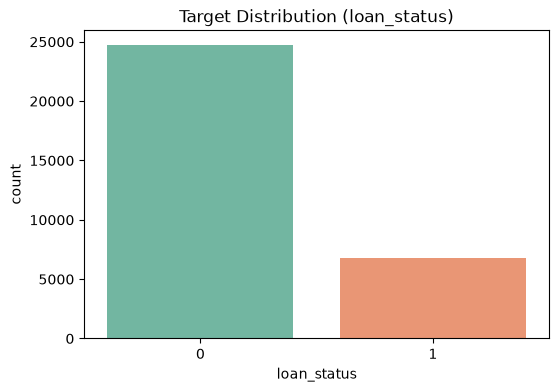

In [7]:

#  UNIVARIATE ANALYSIS

# Numerical Distributions
num_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']
df[num_cols].hist(bins=30, figsize=(12, 8), edgecolor='black')
plt.suptitle("Univariate Analysis: Numerical Features Distribution", fontsize=16)
plt.tight_layout()
plt.show()

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.title("Target Distribution (loan_status)")
plt.show()

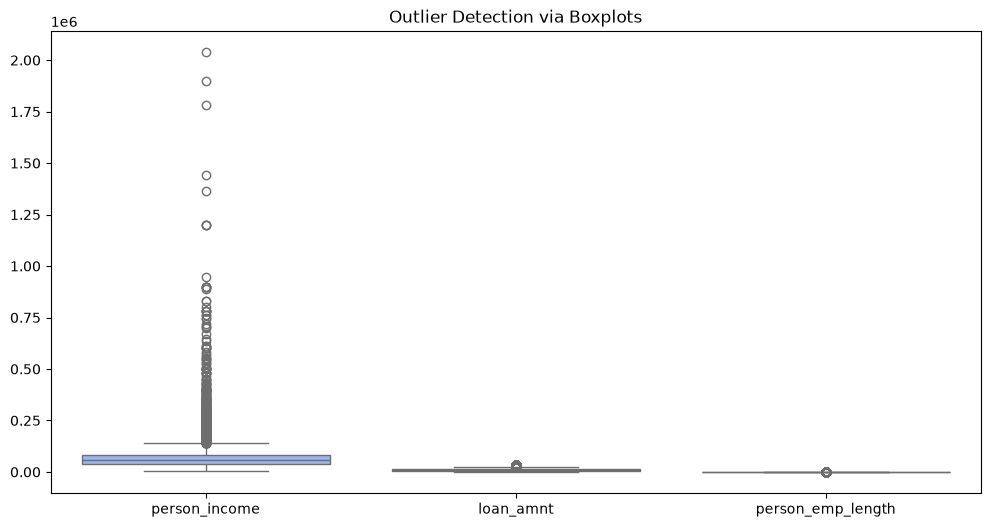

In [8]:

# OUTLIER ANALYSIS & TREATMENT DECISION

# Visualizing Outliers via Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['person_income', 'loan_amnt', 'person_emp_length']], palette='coolwarm')
plt.title("Outlier Detection via Boxplots")
plt.show()



### Decision: For financial columns like income and loan amount, extreme values 
### represent true high-net-worth or large-loan behavior. We retain them 
### so tree-based models (XGBoost/Random Forest) can learn non-linear splits.

In [9]:
#Transformation / Skewness Analysis
print("Skewness of Numerical Features:")
print(df[num_cols].skew())

Skewness of Numerical Features:
person_age             1.946607
person_income          9.837391
loan_amnt              1.181479
loan_int_rate          0.202454
loan_percent_income    1.067868
dtype: float64


###  Note: Highly skewed features like 'person_income' can be log-transformed 
### if using distance-based models, but tree models handle skewness natively

C:\Users\btirk\AppData\Local\Temp\ipykernel_14964\4209011349.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='loan_intent', y='loan_status', data=df, ci=None, palette='viridis')
C:\Users\btirk\AppData\Local\Temp\ipykernel_14964\4209011349.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='loan_intent', y='loan_status', data=df, ci=None, palette='viridis')


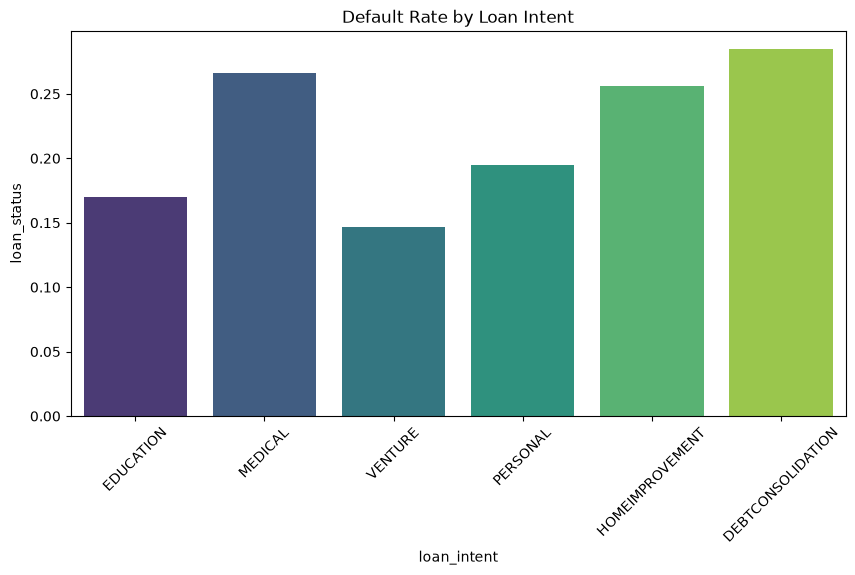

C:\Users\btirk\AppData\Local\Temp\ipykernel_14964\4209011349.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='loan_grade', y='loan_status', data=df, ci=None, order=['A','B','C','D','E','F','G'], palette='magma')
C:\Users\btirk\AppData\Local\Temp\ipykernel_14964\4209011349.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='loan_grade', y='loan_status', data=df, ci=None, order=['A','B','C','D','E','F','G'], palette='magma')


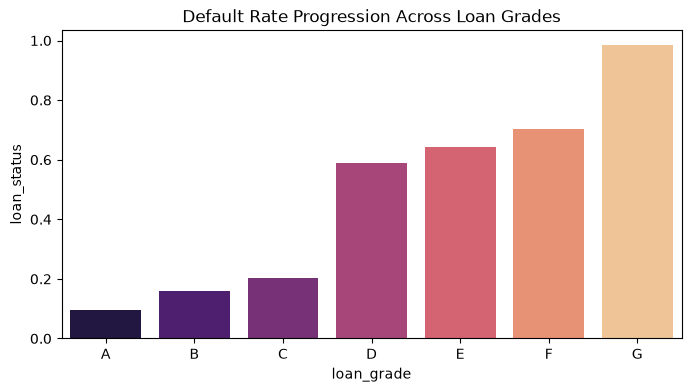

In [10]:
#Bivariate Analysis
# Loan Intent vs Default Rate
plt.figure(figsize=(10, 5))
sns.barplot(x='loan_intent', y='loan_status', data=df, ci=None, palette='viridis')
plt.title("Default Rate by Loan Intent")
plt.xticks(rotation=45)
plt.show()

# Loan Grade vs Default Rate
plt.figure(figsize=(8, 4))
sns.barplot(x='loan_grade', y='loan_status', data=df, ci=None, order=['A','B','C','D','E','F','G'], palette='magma')
plt.title("Default Rate Progression Across Loan Grades")
plt.show()

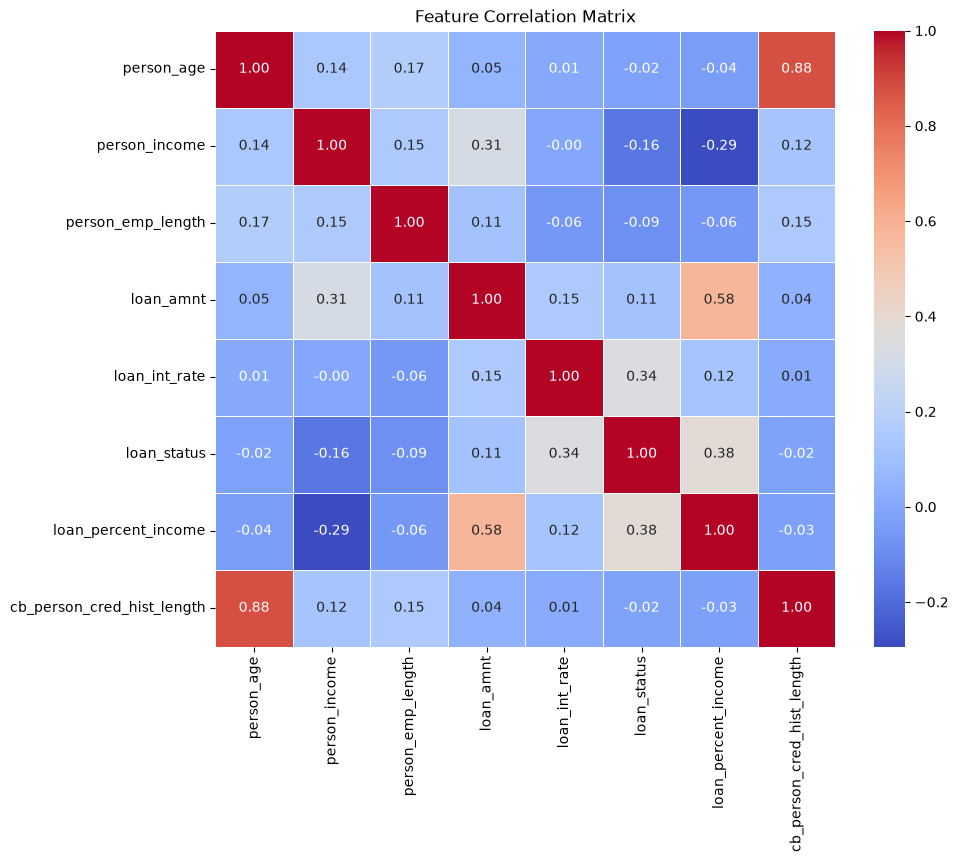

In [11]:
#Multivariate Analysis
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

In [12]:
#Class Imbalance Analysis
class_counts = df['loan_status'].value_counts()
print(class_counts)
print(f"Default Class Percentage: {(class_counts[1] / len(df)) * 100:.2f}%")
print("Conclusion: Moderate imbalance (~21.8% defaults). SMOTE will be applied to training splits.")

loan_status
0    24715
1     6807
Name: count, dtype: int64
Default Class Percentage: 21.59%
Conclusion: Moderate imbalance (~21.8% defaults). SMOTE will be applied to training splits.


In [14]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr(method='pearson')  # can use 'spearman' or 'kendall' as well
print(corr_matrix)

                            person_age  person_income  person_emp_length  \
person_age                    1.000000       0.141604           0.172481   
person_income                 0.141604       1.000000           0.154411   
person_emp_length             0.172481       0.154411           1.000000   
loan_amnt                     0.052180       0.313917           0.111086   
loan_int_rate                 0.009504      -0.003729          -0.058474   
loan_status                  -0.023164      -0.164862          -0.086313   
loan_percent_income          -0.040191      -0.293673          -0.058462   
cb_person_cred_hist_length    0.878412       0.123892           0.149619   

                            loan_amnt  loan_int_rate  loan_status  \
person_age                   0.052180       0.009504    -0.023164   
person_income                0.313917      -0.003729    -0.164862   
person_emp_length            0.111086      -0.058474    -0.086313   
loan_amnt                    1.000000  

In [ ]:
#BUSINESS KPIs
total_applications = len(df)
default_rate = df['loan_status'].mean() * 100
non_default_rate = (1 - df['loan_status'].mean()) * 100
avg_loan_amount = df['loan_amnt'].mean()
avg_income = df['person_income'].mean()
avg_interest_rate = df['loan_int_rate'].mean()
avg_loan_burden = df['loan_percent_income'].mean() * 100

print("=" * 50)
print("       CREDIT RISK PORTFOLIO - EXECUTIVE KPIs       ")
print("=" * 50)
print(f"Total Loan Applications     : {total_applications:,}")
print(f"Overall Default Rate        : {default_rate:.2f}%")
print(f"Non-Default Rate            : {non_default_rate:.2f}%")
print(f"Average Loan Amount         : ${avg_loan_amount:,.2f}")
print(f"Average Annual Income       : ${avg_income:,.2f}")
print(f"Average Interest Rate       : {avg_interest_rate:.2f}%")
print(f"Average Loan Burden (DTI)   : {avg_loan_burden:.2f}% of income")
print("=" * 50)

       CREDIT RISK PORTFOLIO - EXECUTIVE KPIs       
Total Loan Applications     : 31,522
Overall Default Rate        : 21.59%
Non-Default Rate            : 78.41%
Average Loan Amount         : $9,663.77
Average Annual Income       : $66,501.68
Average Interest Rate       : 11.05%
Average Loan Burden (DTI)   : 16.97% of income


### Summary & Business Insights
Based on the portfolio's key performance indicators, we can draw the following core insights regarding risk exposure and borrower characteristics:

Portfolio Scale & Distribution: The dataset comprises 31,522 qualified loan applications, establishing a strong and statistically significant sample size for training predictive risk models.

Class Imbalance & Risk Profile: The portfolio exhibits an overall default rate of 21.59% (non-default rate of 78.41%). This confirms a moderate class imbalance, validating the planned use of SMOTE strictly on training splits to prevent model bias.

Affordability & Debt-to-Income (DTI): On average, borrowers allocate 16.97% of their annual income toward loan repayments (loan_percent_income), with an average loan amount of $9,663.77 against an average annual income of $66,501.68.

Pricing & Risk Alignment: The average interest rate stands at 11.05%, reflecting standard risk-based pricing strategies across varying credit grades.

In [17]:

# PHASE 1 FINAL: CATEGORICAL RISK DRIVERS ("Why / Where?")


print("--- Default Rate by Loan Grade ---")
display(df.groupby('loan_grade')['loan_status'].mean().mul(100).round(2).astype(str) + '%')

print("\n--- Default Rate by Loan Intent ---")
display(df.groupby('loan_intent')['loan_status'].mean().mul(100).round(2).astype(str) + '%')

print("\n--- Default Rate by Home Ownership ---")
display(df.groupby('person_home_ownership')['loan_status'].mean().mul(100).round(2).astype(str) + '%')

print("\n--- Default Rate by Historical Default on File ---")
display(df.groupby('cb_person_default_on_file')['loan_status'].mean().mul(100).round(2).astype(str) + '%')

--- Default Rate by Loan Grade ---


loan_grade
A     9.56%
B    15.97%
C    20.31%
D    58.78%
E    64.25%
F    70.34%
G    98.44%
Name: loan_status, dtype: str


--- Default Rate by Loan Intent ---


loan_intent
DEBTCONSOLIDATION    28.45%
EDUCATION            16.99%
HOMEIMPROVEMENT      25.61%
MEDICAL               26.6%
PERSONAL             19.51%
VENTURE               14.7%
Name: loan_status, dtype: str


--- Default Rate by Home Ownership ---


person_home_ownership
MORTGAGE     12.5%
OTHER       31.13%
OWN          6.94%
RENT        31.12%
Name: loan_status, dtype: str


--- Default Rate by Historical Default on File ---


cb_person_default_on_file
N    18.12%
Y    37.62%
Name: loan_status, dtype: str

Business insight: 
1.Default rate increases dramatically as loan grade moves from A → G.
2. Default rates vary substantially by loan purpose.
Business insight: The observed default rate differs strongly by home-ownership status.

There is a particularly large gap between:

OWN: 6.94%
RENT: 31.12%

That's approximately a 24 percentage-point difference.

Business implication: Home ownership may provide useful information for risk segmentation, but it should be evaluated alongside income, loan burden, credit history, and other variables rather than used as a standalone decision rule.

In [18]:
# =====================================================
# DATA CONSISTENCY & RECONCILIATION CHECK
# =====================================================
print(f"Current dataset shape: {df.shape}")
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
print(df['loan_status'].value_counts())
print("\nTarget percentage:")
print(df['loan_status'].value_counts(normalize=True).mul(100).round(2))

Current dataset shape: (31522, 12)

Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3027
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Duplicate rows: 0

Target distribution:
loan_status
0    24715
1     6807
Name: count, dtype: int64

Target percentage:
loan_status
0    78.41
1    21.59
Name: proportion, dtype: float64


In [19]:
# =====================================================
# NUMERICAL RISK DRIVERS ANALYSIS
# =====================================================
print("--- Numerical Features: Default vs Non-Default (Means) ---")
display(
    df.groupby('loan_status')[
        ['person_income',
         'loan_amnt',
         'loan_int_rate',
         'loan_percent_income']
    ].mean().round(2)
)

print("\n--- Numerical Features: Default vs Non-Default (Medians) ---")
display(
    df.groupby('loan_status')[
        ['person_income',
         'loan_amnt',
         'loan_int_rate',
         'loan_percent_income']
    ].median().round(2)
)

--- Numerical Features: Default vs Non-Default (Means) ---


,person_income,loan_amnt,loan_int_rate,loan_percent_income
loan_status,,,,
0,71065.75,9289.44,10.47,0.15
1,49930.38,11022.90,13.13,0.25



--- Numerical Features: Default vs Non-Default (Medians) ---


,person_income,loan_amnt,loan_int_rate,loan_percent_income
loan_status,,,,
0,60000.0,8000.0,10.62,0.13
1,42000.0,10000.0,13.49,0.24


### preprocessing

In [22]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

Features shape (X): (31522, 11)
Target shape (y): (31522,)


In [23]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)
print(f"Total features: {len(numerical_cols) + len(categorical_cols)}")

Numerical Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Total features: 11


In [25]:
#train test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Ensures the default ratio (~21.6%) is preserved in both splits
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nTraining set target distribution (Stratified):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

Training set shape: (25217, 11)
Testing set shape: (6305, 11)

Training set target distribution (Stratified):
loan_status
0    78.41
1    21.59
Name: proportion, dtype: float64


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# =====================================================
# STEP 4: DEFINE PREPROCESSING PIPELINE
# =====================================================

# Pipeline for numerical features: Fill missing values with median, then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features: Handle unknown categories safely, then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessor pipeline created successfully!")

Preprocessor pipeline created successfully!


In [27]:
from imblearn.over_sampling import SMOTE

# =====================================================
# STEP 5: APPLY PREPROCESSOR & SMOTE
# =====================================================

# 1. Fit preprocessor on X_train and transform both X_train and X_test
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"X_train transformed shape: {X_train_transformed.shape}")
print(f"X_test transformed shape: {X_test_transformed.shape}")

# 2. Apply SMOTE strictly to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

print("\n--- After SMOTE on Training Data ---")
print(f"Resampled X_train shape: {X_train_resampled.shape}")
print(f"Resampled y_train shape: {y_train_resampled.shape}")
print("New class distribution in y_train_resampled:")
print(y_train_resampled.value_counts())

X_train transformed shape: (25217, 26)
X_test transformed shape: (6305, 26)


C:\Users\btirk\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\btirk\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "e:\credit-risk-prediction\venv\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\credit-risk-prediction\venv\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "e:\credit-risk-prediction\venv\Lib\subprocess.py", line 1538, in


--- After SMOTE on Training Data ---
Resampled X_train shape: (39544, 26)
Resampled y_train shape: (39544,)
New class distribution in y_train_resampled:
loan_status
0    19772
1    19772
Name: count, dtype: int64


Model Building & Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


#  MODEL TRAINING &


# 1. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr_model.predict(X_test_transformed)
y_proba_lr = lr_model.predict_proba(X_test_transformed)[:, 1]

# 2. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_transformed)
y_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]

print("Models trained successfully!")

Models trained successfully!


In [29]:
#model evaluation
print("--- Logistic Regression Performance ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

print("\n--- Random Forest Classifier Performance ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

--- Logistic Regression Performance ---
ROC-AUC Score: 0.8746
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.78      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305


--- Random Forest Classifier Performance ---
ROC-AUC Score: 0.9320
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.93      0.73      0.82      1362

    accuracy                           0.93      6305
   macro avg       0.93      0.86      0.89      6305
weighted avg       0.93      0.93      0.93      6305



In [30]:
#Metric-Based Overfitting Check (Train vs. Test)
from sklearn.metrics import accuracy_score, roc_auc_score

# =====================================================
# OVERFITTING CHECK: METRICS (TRAIN VS TEST)
# =====================================================

def evaluate_overfitting(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Training predictions
    train_preds = model.predict(X_train)
    train_proba = model.predict_proba(X_train)[:, 1]
    train_acc = accuracy_score(y_train, train_preds)
    train_auc = roc_auc_score(y_train, train_proba)
    
    # Test predictions
    test_preds = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]
    test_acc = accuracy_score(y_test, test_preds)
    test_auc = roc_auc_score(y_test, test_proba)
    
    print(f"=== {model_name} Performance Check ===")
    print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")
    print(f"Train ROC-AUC : {train_auc:.4f} | Test ROC-AUC : {test_auc:.4f}")
    print("-" * 40)

evaluate_overfitting(lr_model, X_train_resampled, y_train_resampled, X_test_transformed, y_test, "Logistic Regression")
evaluate_overfitting(rf_model, X_train_resampled, y_train_resampled, X_test_transformed, y_test, "Random Forest")

=== Logistic Regression Performance Check ===
Train Accuracy: 0.8026 | Test Accuracy: 0.8208
Train ROC-AUC : 0.8756 | Test ROC-AUC : 0.8746
----------------------------------------
=== Random Forest Performance Check ===
Train Accuracy: 1.0000 | Test Accuracy: 0.9308
Train ROC-AUC : 1.0000 | Test ROC-AUC : 0.9320
----------------------------------------


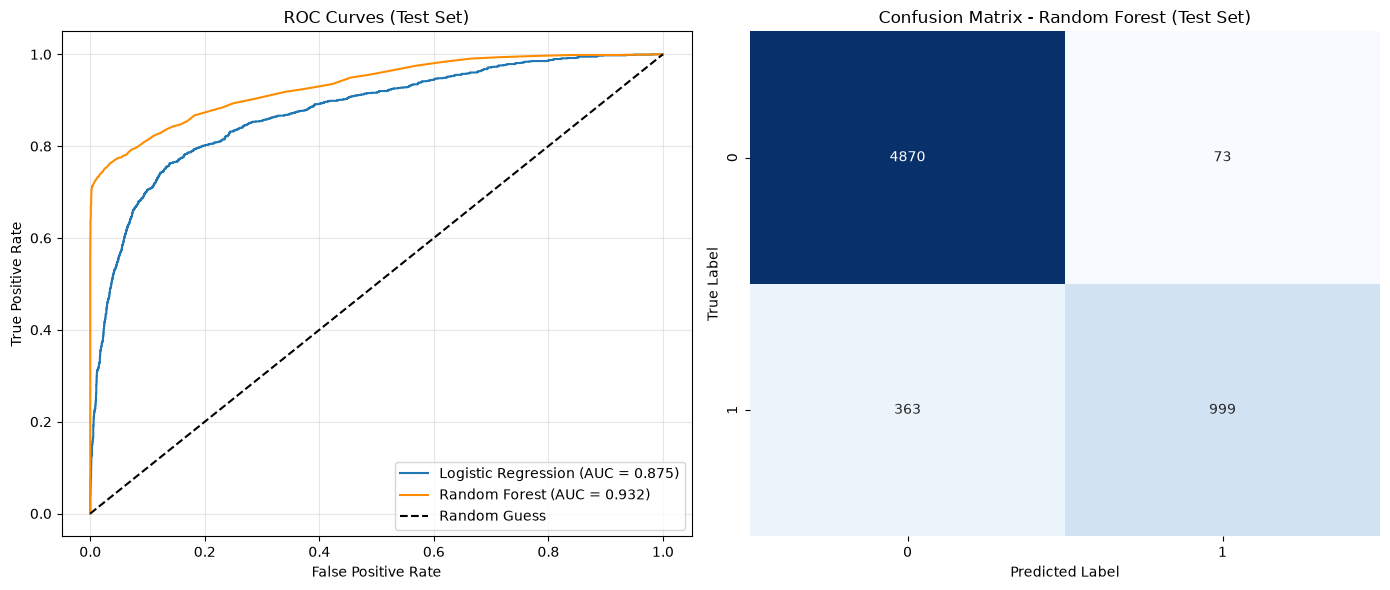

In [31]:
#Visualization-Based Overfitting Check (ROC Curves & Confusion Matrices)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

# =====================================================
# OVERFITTING CHECK: VISUALIZATIONS
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})', color='darkorange')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (Test Set)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# 2. Confusion Matrix for Random Forest (Test Set)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix - Random Forest (Test Set)')

plt.tight_layout()
plt.show()

In [32]:
#Hyperparameter Tuning for Logistic Regression
from sklearn.model_selection import GridSearchCV

# =====================================================
# HYPERPARAMETER TUNING: LOGISTIC REGRESSION
# =====================================================

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supports both l1 and l2
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train_resampled, y_train_resampled)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)
print(f"Best CV ROC-AUC: {lr_grid.best_score_:.4f}")

# Save the best model
best_lr_model = lr_grid.best_estimator_

Best Logistic Regression Parameters:
{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.8753


In [33]:
#Hyperparameter Tuning for Random Forest
from sklearn.model_selection import RandomizedSearchCV

# =====================================================
# HYPERPARAMETER TUNING: RANDOM FOREST
# =====================================================

rf_param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_distributions,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_resampled, y_train_resampled)

print("Best Random Forest Parameters:")
print(rf_random.best_params_)
print(f"Best CV ROC-AUC: {rf_random.best_score_:.4f}")

# Save the best model
best_rf_model = rf_random.best_estimator_

Best Random Forest Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.9866


In [ ]:
#adding XGBoost Classifier
from xgboost import XGBClassifier

# =====================================================
# XGBOOST CLASSIFIER
# =====================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_resampled, y_train_resampled)

print("XGBoost Model trained successfully!")

XGBoost Model trained successfully!


In [35]:
#Unified Evaluation & Comparison Table
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import pandas as pd

# =====================================================
# FINAL BENCHMARK COMPARISON
# =====================================================

models = {
    "Tuned Logistic Regression": best_lr_model,
    "Tuned Random Forest": best_rf_model,
    "XGBoost Classifier": xgb_model
}

evaluation_results = []

for name, model in models.items():
    preds = model.predict(X_test_transformed)
    proba = model.predict_proba(X_test_transformed)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    
    # Get classification report dict for class 1 (default) metrics
    report = classification_report(y_test, preds, output_dict=True)
    f1_default = report['1']['f1-score']
    precision_default = report['1']['precision']
    recall_default = report['1']['recall']
    
    evaluation_results.append({
        "Model": name,
        "Test Accuracy": round(acc, 4),
        "Test ROC-AUC": round(auc, 4),
        "Default Precision": round(precision_default, 4),
        "Default Recall": round(recall_default, 4),
        "Default F1-Score": round(f1_default, 4)
    })

results_df = pd.DataFrame(evaluation_results)
display(results_df)

,Model,Test Accuracy,Test ROC-AUC,Default Precision,Default Recall,Default F1-Score
0,Tuned Logistic Regression,0.8206,0.8747,0.5607,0.7834,0.6536
1,Tuned Random Forest,0.9316,0.9334,0.9290,0.7401,0.8239
2,XGBoost Classifier,0.9318,0.9352,0.9347,0.7357,0.8233


In [36]:
import joblib
import os

# Create artifacts directory if it doesn't exist
os.makedirs("artifacts", exist_ok=True)

# Save the winning XGBoost model and preprocessor
joblib.dump(xgb_model, "artifacts/best_model.pkl")
joblib.dump(preprocessor, "artifacts/preprocessor.pkl")

# Save evaluation results table
results_df.to_csv("artifacts/model_results.csv", index=False)

print("Artifacts successfully saved to 'artifacts/' folder!")

Artifacts successfully saved to 'artifacts/' folder!
